<a href="https://colab.research.google.com/github/yeeshukanda-source/AAI2025/blob/main/part_1_part_2_Part_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Part 1: House Price Prediction Using Linear Regression

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score


# ---------------------------------------------------------
# DATA SOURCE:
# House Sales in King County, USA
# Kaggle:
# https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
# ---------------------------------------------------------

# Load the CSV file
df = pd.read_csv("kc_house_data.csv")

# Keep only the columns needed
df = df[['sqft_living', 'price']].copy()

# Rename column
df.rename(columns={'sqft_living': 'square_footage'}, inplace=True)

# Remove missing values
df = df.dropna()

# Create location categories
np.random.seed(42)

df['location'] = np.random.choice(
    ['Downtown', 'Suburb', 'Rural'],
    size=len(df),
    p=[0.35, 0.45, 0.20]
)

# Display dataset information
print("Number of records:", len(df))

print("\nFirst 5 rows:")
print(df.head())


# ---------------------------------------------------------
# FEATURES AND TARGET
# ---------------------------------------------------------

X = df[['square_footage', 'location']]
y = df['price']


# ---------------------------------------------------------
# PREPROCESSING
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            'location',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            ['location']
        )
    ],
    remainder='passthrough'
)


# ---------------------------------------------------------
# CREATE MODEL
# ---------------------------------------------------------

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)


# ---------------------------------------------------------
# SPLIT DATA
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------------
# TRAIN MODEL
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# TEST MODEL
# ---------------------------------------------------------

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-squared Score: {r2:.3f}")


# ---------------------------------------------------------
# PREDICT A 2000 SQ FT DOWNTOWN HOUSE
# ---------------------------------------------------------

new_house = pd.DataFrame({
    'square_footage': [2000],
    'location': ['Downtown']
})

predicted_price = model.predict(new_house)

print(
    f"\nPredicted price for a 2000 sq ft house in Downtown: "
    f"${predicted_price[0]:,.2f}"
)


# ---------------------------------------------------------
# DISPLAY MODEL COEFFICIENTS
# ---------------------------------------------------------

location_features = (
    model.named_steps['preprocessor']
    .named_transformers_['location']
    .get_feature_names_out(['location'])
    .tolist()
)

feature_names = location_features + ['square_footage']

coefficients = model.named_steps['regressor'].coef_

print("\nModel Coefficients:")

for feature, coefficient in zip(feature_names, coefficients):
    print(f"{feature}: ${coefficient:,.2f}")


# ---------------------------------------------------------
# EXPLAIN SQUARE FOOTAGE COEFFICIENT
# ---------------------------------------------------------

sqft_index = feature_names.index('square_footage')

sqft_coefficient = coefficients[sqft_index]

print("\nCoefficient Explanation:")

print(
    f"For each additional square foot, the model predicts "
    f"the house price will change by approximately "
    f"${sqft_coefficient:,.2f}, while location stays the same."
)

print(
    "The location coefficients show how predicted prices "
    "differ between locations after accounting for square footage."
)

Number of records: 21613

First 5 rows:
   square_footage     price  location
0            1180  221900.0    Suburb
1            2570  538000.0     Rural
2             770  180000.0    Suburb
3            1960  604000.0    Suburb
4            1680  510000.0  Downtown

Model Performance:
Mean Absolute Error: $177,899.42
R-squared Score: 0.494

Predicted price for a 2000 sq ft house in Downtown: $514,720.93

Model Coefficients:
location_Rural: $-875.64
location_Suburb: $5,678.83
square_footage: $279.56

Coefficient Explanation:
For each additional square foot, the model predicts the house price will change by approximately $279.56, while location stays the same.
The location coefficients show how predicted prices differ between locations after accounting for square footage.


In [9]:
# Part 2: Customer Churn Prediction Using Logistic Regression

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


# ---------------------------------------------------------
# DATA SOURCE:
# IBM Telco Customer Churn Dataset
# Kaggle:
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn
#
# The dataset contains more than 7,000 customer records.
# ---------------------------------------------------------


# Load the CSV file
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


# ---------------------------------------------------------
# DATA CLEANING
# ---------------------------------------------------------

# Convert TotalCharges to numeric
# Some records contain blank values.
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Remove rows with missing values
df = df.dropna()


# Convert Churn from Yes/No to 1/0
df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})


# ---------------------------------------------------------
# SELECT FEATURES
# ---------------------------------------------------------

features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Contract',
    'InternetService',
    'PaymentMethod'
]

X = df[features]
y = df['Churn']


# ---------------------------------------------------------
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ---------------------------------------------------------

numerical_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

categorical_features = [
    'Contract',
    'InternetService',
    'PaymentMethod'
]


# ---------------------------------------------------------
# PREPROCESSING
#
# StandardScaler scales numerical features.
# OneHotEncoder converts categorical features into numbers.
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numerical',
            StandardScaler(),
            numerical_features
        ),
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        )
    ]
)


# ---------------------------------------------------------
# CREATE LOGISTIC REGRESSION MODEL
# ---------------------------------------------------------

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(max_iter=1000)
        )
    ]
)


# ---------------------------------------------------------
# SPLIT DATA INTO TRAINING AND TESTING DATA
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ---------------------------------------------------------
# TRAIN MODEL
# ---------------------------------------------------------

model.fit(X_train, y_train)


# ---------------------------------------------------------
# PREDICT CHURN
# ---------------------------------------------------------

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ---------------------------------------------------------
# PREDICT CHURN PROBABILITY
# ---------------------------------------------------------

# Example new customer
new_customer = pd.DataFrame({
    'SeniorCitizen': [0],
    'tenure': [6],
    'MonthlyCharges': [85.50],
    'TotalCharges': [513.00],
    'Contract': ['Month-to-month'],
    'InternetService': ['Fiber optic'],
    'PaymentMethod': ['Electronic check']
})


# Get probability of churn
churn_probability = model.predict_proba(new_customer)[0][1]


print("\nNew Customer Churn Prediction:")
print(
    f"Probability of churn: "
    f"{churn_probability * 100:.2f}%"
)


# ---------------------------------------------------------
# CLASSIFY CUSTOMER USING 0.5 THRESHOLD
# ---------------------------------------------------------

threshold = 0.5

if churn_probability >= threshold:
    churn_prediction = 1
    print("Prediction: Customer is at risk of churning.")
else:
    churn_prediction = 0
    print("Prediction: Customer is not classified as at risk.")


# ---------------------------------------------------------
# BUSINESS INTERPRETATION
# ---------------------------------------------------------

print("\nBusiness Interpretation:")

if churn_prediction == 1:
    print(
        "The customer has a high enough probability of churning "
        "to be considered at risk. The company could offer a "
        "discount, improved service plan, or contact the customer "
        "to understand their concerns."
    )
else:
    print(
        "The customer is currently below the 0.5 churn threshold. "
        "The company can continue normal customer engagement while "
        "monitoring the customer's future behavior."
    )

Model Accuracy: 0.799

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407


New Customer Churn Prediction:
Probability of churn: 67.33%
Prediction: Customer is at risk of churning.

Business Interpretation:
The customer has a high enough probability of churning to be considered at risk. The company could offer a discount, improved service plan, or contact the customer to understand their concerns.


Number of customers: 7032

Features used for clustering:
   tenure  MonthlyCharges  TotalCharges  SeniorCitizen
0       1           29.85         29.85              0
1      34           56.95       1889.50              0
2       2           53.85        108.15              0
3      45           42.30       1840.75              0
4       2           70.70        151.65              0


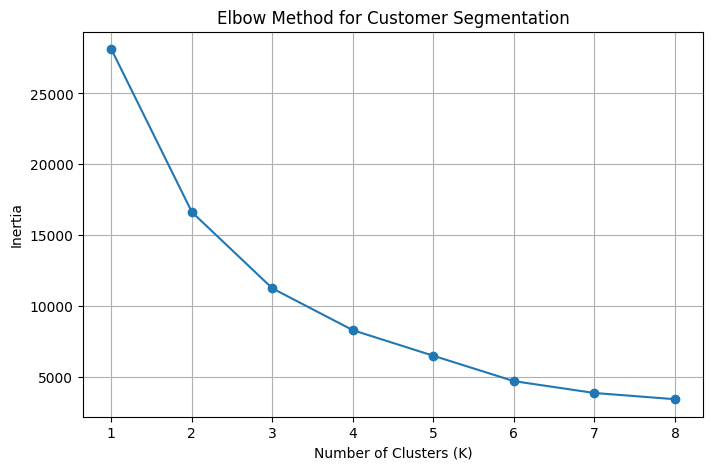


Average Characteristics of Each Cluster:
         tenure  MonthlyCharges  TotalCharges  SeniorCitizen
Cluster                                                     
0         57.24           88.63       5056.32            0.0
1         20.58           49.40        838.36            0.0
2         33.30           79.82       2810.47            1.0

Number of Customers in Each Cluster:
Cluster 0: 1875 customers
Cluster 1: 4015 customers
Cluster 2: 1142 customers

Marketing Strategies:

Cluster 0:
Average monthly charges: $88.63
Average tenure: 57.2 months
Strategy: Target this group with premium services, exclusive promotions, and loyalty rewards.

Cluster 1:
Average monthly charges: $49.40
Average tenure: 20.6 months
Strategy: Offer new-customer discounts, onboarding support, and incentives for longer-term contracts.

Cluster 2:
Average monthly charges: $79.82
Average tenure: 33.3 months
Strategy: Use personalized promotions and bundle offers to increase customer engagement and spending.


In [10]:
# Part 3: Customer Segmentation Using K-Means

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ---------------------------------------------------------
# DATA SOURCE:
# IBM Telco Customer Churn Dataset
# Kaggle:
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn
#
# The dataset contains more than 7,000 customer records.
# ---------------------------------------------------------


# Load the CSV file
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


# ---------------------------------------------------------
# DATA CLEANING
# ---------------------------------------------------------

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Remove rows with missing values
df = df.dropna()


# ---------------------------------------------------------
# SELECT FEATURES FOR CUSTOMER SEGMENTATION
# ---------------------------------------------------------

features = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'SeniorCitizen'
]

X = df[features].copy()


print("Number of customers:", len(X))

print("\nFeatures used for clustering:")
print(X.head())


# ---------------------------------------------------------
# SCALE THE NUMERICAL FEATURES
# ---------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------
# ELBOW METHOD
# Test different values of K
# ---------------------------------------------------------

inertia = []

k_values = range(1, 9)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


# ---------------------------------------------------------
# CREATE ELBOW PLOT
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method for Customer Segmentation")

plt.xticks(k_values)

plt.grid(True)

plt.savefig("elbow_plot.png")

plt.show()


# ---------------------------------------------------------
# APPLY K-MEANS
#
# Based on the elbow plot, K=3 is selected.
# ---------------------------------------------------------

k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)


# ---------------------------------------------------------
# ANALYZE CLUSTERS
# ---------------------------------------------------------

cluster_summary = df.groupby('Cluster')[features].mean()

print("\nAverage Characteristics of Each Cluster:")
print(cluster_summary.round(2))


# ---------------------------------------------------------
# SHOW NUMBER OF CUSTOMERS IN EACH CLUSTER
# ---------------------------------------------------------

cluster_counts = df['Cluster'].value_counts().sort_index()

print("\nNumber of Customers in Each Cluster:")

for cluster, count in cluster_counts.items():

    print(f"Cluster {cluster}: {count} customers")


# ---------------------------------------------------------
# MARKETING STRATEGIES
# ---------------------------------------------------------

print("\nMarketing Strategies:")

for cluster in cluster_summary.index:

    spending = cluster_summary.loc[cluster, 'MonthlyCharges']
    tenure = cluster_summary.loc[cluster, 'tenure']

    print(f"\nCluster {cluster}:")

    print(
        f"Average monthly charges: ${spending:.2f}"
    )

    print(
        f"Average tenure: {tenure:.1f} months"
    )

    if spending > cluster_summary['MonthlyCharges'].median():

        print(
            "Strategy: Target this group with premium services, "
            "exclusive promotions, and loyalty rewards."
        )

    elif tenure < cluster_summary['tenure'].median():

        print(
            "Strategy: Offer new-customer discounts, onboarding "
            "support, and incentives for longer-term contracts."
        )

    else:

        print(
            "Strategy: Use personalized promotions and bundle "
            "offers to increase customer engagement and spending."
        )


# ---------------------------------------------------------
# SAVE RESULTS TO CSV
# ---------------------------------------------------------

df.to_csv(
    "customer_segments.csv",
    index=False
)

print("\nCluster results saved to:")
print("customer_segments.csv")